# 📓 LGBM-02: Feature Engineering


### Code làm gì?
Build **8 nhóm feature** từ sequence, validate bằng RF importance, save ra CSV.

| Group | Tên | Mô tả | Lý do |
|-------|-----|-------|---------|
| G1 | Sequence Stats | length, unique ratio | seq_len = top-12 gain |
| G2 | Positional Tokens | first/last 5 tokens | tok_neg_1 = feature #1 |
| G3 | Token Chains | bigram/trigram hashes | capture ending pattern |
| G4 | Statistical | mean/std/head/tail | phân bố giá trị |
| G5 | Repetition | rollback/update signals | order modification behavior |
| G6 | Bag-of-Actions | count vector top-50 | action frequency |
| G7 | Interaction Features | last_tok × seq_len, etc. | non-linear combinations |
| G8 | Meta Cols | feature_1, feature_2... | user/session metadata |

**Output** → `train_feats.csv`, `val_feats.csv`, `test_feats.csv`, `feat_meta.pkl`

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle, warnings, os
warnings.filterwarnings('ignore')

TARGET_COLS = ['attr_1','attr_2','attr_3','attr_4','attr_5','attr_6']
print('✅ Import done')

Mounted at /content/drive
✅ Import done


## 1. Load từ NB-01

In [ ]:
with open('/content/drive/MyDrive/sailormoon/data/pipeline/sequences.pkl',  'rb') as f: seqs    = pickle.load(f)
with open('/content/drive/MyDrive/sailormoon/data/pipeline/meta.pkl',        'rb') as f: meta    = pickle.load(f)
with open('/content/drive/MyDrive/sailormoon/data/pipeline/token_stats.pkl', 'rb') as f: tstats  = pickle.load(f)
with open('/content/drive/MyDrive/sailormoon/data/pipeline/encoders.pkl',    'rb') as f: encoders = pickle.load(f)

train_seqs    = seqs['train']
val_seqs      = seqs['val']
test_seqs     = seqs['test']
meta_cols     = meta['meta_cols']
N_train       = meta['N_train']
token_counter = tstats['counter']

X_train     = pd.read_csv('/content/drive/MyDrive/sailormoon/data/X_train.csv', index_col='id')
X_val       = pd.read_csv('/content/drive/MyDrive/sailormoon/data/X_val.csv',   index_col='id')
X_test      = pd.read_csv('/content/drive/MyDrive/sailormoon/data/X_test.csv',  index_col='id')
Y_train_enc = pd.read_csv('/content/drive/MyDrive/sailormoon/data/pipeline/Y_train_enc.csv', index_col='id')
Y_val_enc   = pd.read_csv('/content/drive/MyDrive/sailormoon/data/pipeline/Y_val_enc.csv',   index_col='id')

# Top-50 tokens cho BOW
TOP_N      = 50
top_tokens = [t for t,_ in token_counter.most_common(TOP_N)]
print(f'✅ Loaded  |  TOP_N={TOP_N}  |  top 10 tokens: {top_tokens[:10]}')

✅ Loaded  |  TOP_N=50  |  top 10 tokens: [105, 102, 8615, 103, 697, 975, 760, 1068, 685, 21355]


## 2. Feature Extractor — 8 Groups
> Mỗi group có comment giải thích **lý do** tại sao feature đó quan trọng

In [ ]:
def extract_features(seq, top_tokens, token_counter, N_train):
    """
    Input : seq          — list of int tokens
    Output: dict of features
    """
    n = len(seq)
    if n == 0:
        seq = [0]; n = 1
    c = Counter(seq)
    f = {}

    # ═══════════════════════════════════════════════════════════════
    # G1 · SEQUENCE STATS
    # seq_len = #12 global gain trong RF/LightGBM baseline
    # unique_ratio đo 'độ đa dạng' của session
    # ═══════════════════════════════════════════════════════════════
    f['seq_len']      = n
    f['log_seq_len']  = np.log1p(n)
    f['n_unique']     = len(c)
    f['unique_ratio'] = len(c) / n
    f['sqrt_seq_len'] = np.sqrt(n)            # smooth version của seq_len

    # ═══════════════════════════════════════════════════════════════
    # G2 · POSITIONAL TOKENS
    # tok_neg_1 (last token) = feature #1 toàn cục!
    # Last token thường encode trạng thái cuối của transaction
    # First token thường encode loại session / entry point
    # ═══════════════════════════════════════════════════════════════
    for k in range(5):
        f[f'tok_head_{k}'] = seq[k]      if n > k else -1    # first 5
        f[f'tok_tail_{k}'] = seq[-(k+1)] if n > k else -1    # last 5

    # ═══════════════════════════════════════════════════════════════
    # G3 · TOKEN CHAINS (ending/starting patterns)
    # LightGBM học được: 'nếu 3 token cuối = (A,B,C) → attr_3 = X'
    # Hash mod prime để tránh collision nhưng vẫn compact
    # ═══════════════════════════════════════════════════════════════
    MOD = 1_000_003
    f['last_1gram']      = seq[-1]
    f['last_2gram_hash'] = hash((seq[-2], seq[-1]))           % MOD if n >= 2 else -1
    f['last_3gram_hash'] = hash((seq[-3], seq[-2], seq[-1]))  % MOD if n >= 3 else -1
    f['last_4gram_hash'] = hash(tuple(seq[-4:]))              % MOD if n >= 4 else -1
    f['first_3gram_hash']= hash(tuple(seq[:3]))               % MOD if n >= 3 else -1
    f['full_hash']       = hash(tuple(seq))                   % MOD if n <= 8  else -1
    # raw last-3 (không hash) để LightGBM có thể split trực tiếp
    f['last3_a'] = seq[-3] if n >= 3 else seq[-1]
    f['last3_b'] = seq[-2] if n >= 2 else seq[-1]
    f['last3_c'] = seq[-1]

    # ═══════════════════════════════════════════════════════════════
    # G4 · STATISTICAL FEATURES
    # head/mid/tail mean capture 'trend' của sequence
    # tok_skew: phân bố lệch → có nhiều rare product IDs không?
    # ═══════════════════════════════════════════════════════════════
    f['tok_mean']   = float(np.mean(seq))
    f['tok_std']    = float(np.std(seq))     if n > 1 else 0.0
    f['tok_min']    = float(np.min(seq))
    f['tok_max']    = float(np.max(seq))
    f['tok_median'] = float(np.median(seq))
    f['tok_range']  = f['tok_max'] - f['tok_min']
    f['tok_skew']   = float(pd.Series(seq).skew())  if n > 2 else 0.0

    third = max(1, n // 3)
    head  = seq[:third]
    tail  = seq[-third:]
    mid   = seq[third:-third] if n > 2*third else seq
    f['head_mean']      = float(np.mean(head))
    f['mid_mean']       = float(np.mean(mid))
    f['tail_mean']      = float(np.mean(tail))
    f['head_tail_diff'] = f['tail_mean'] - f['head_mean']   # trend: tăng hay giảm?
    f['tail_last_diff'] = float(seq[-1])  - f['tail_mean']  # last khác tail không?

    tail10 = seq[-10:]
    f['tail10_mean']    = float(np.mean(tail10))
    f['tail10_nunique'] = len(set(tail10))
    f['tail10_std']     = float(np.std(tail10)) if len(tail10) > 1 else 0.0

    # ═══════════════════════════════════════════════════════════════
    # G5 · REPETITION FEATURES
    # Rollback / update behavior: order bị sửa nhiều lần?
    # repeated_ratio cao → nhiều rollback actions
    # last_tok_freq: last action bị lặp nhiều → bị retry?
    # ═══════════════════════════════════════════════════════════════
    n_rep = sum(1 for v in c.values() if v > 1)
    f['n_repeated_toks']  = n_rep
    f['repeated_ratio']   = n_rep / max(len(c), 1)
    f['total_repeats']    = sum(v-1 for v in c.values())
    f['last_tok_freq']    = c.get(seq[-1], 1)
    f['last_tok_is_rare'] = int(token_counter.get(seq[-1], 0) / N_train < 0.01)
    mc_tok, mc_cnt = c.most_common(1)[0]
    f['most_common_tok']   = mc_tok
    f['most_common_cnt']   = mc_cnt
    f['most_common_ratio'] = mc_cnt / n
    # consecutive repeats (e.g. A A A B → 2 consecutive)
    consec = sum(1 for i in range(n-1) if seq[i] == seq[i+1])
    f['consec_repeat_cnt'] = consec
    f['consec_repeat_ratio']= consec / max(n-1, 1)

    # ═══════════════════════════════════════════════════════════════
    # G6 · BAG-OF-ACTIONS (count vector)
    # Đếm tần suất từng action type trong session
    # top_tokens thường là các action types phổ biến nhất
    # ═══════════════════════════════════════════════════════════════
    for tok in top_tokens:
        f[f'cnt_{tok}'] = c.get(tok, 0)

    rare_set = {t for t in seq if token_counter.get(t,0)/N_train < 0.01}
    f['rare_tok_ratio']  = sum(1 for t in seq if t in rare_set) / n
    f['n_rare_unique']   = len(rare_set)

    if n >= 2:
        bgs = [(seq[j], seq[j+1]) for j in range(n-1)]
        bgc = Counter(bgs)
        f['n_unique_bigrams']  = len(bgc)
        f['bigram_rep_ratio']  = (len(bgs) - len(bgc)) / max(len(bgs), 1)
        top_bg = bgc.most_common(1)[0][0]
        f['top_bigram_a']      = top_bg[0]
        f['top_bigram_b']      = top_bg[1]
        f['last_bigram_a']     = seq[-2]
        f['last_bigram_b']     = seq[-1]
    else:
        f['n_unique_bigrams'] = 0; f['bigram_rep_ratio'] = 0
        f['top_bigram_a']     = -1; f['top_bigram_b']    = -1
        f['last_bigram_a']    = -1; f['last_bigram_b']   = seq[-1]

    # ═══════════════════════════════════════════════════════════════
    # G7 · INTERACTION FEATURES
    # Kết hợp non-linear giữa các features quan trọng
    # LightGBM chỉ học được splits bậc 1 → cần pre-compute interactions
    # ═══════════════════════════════════════════════════════════════
    f['last_tok_x_seqlen']   = seq[-1]  * np.log1p(n)       # interaction: token + length
    f['last_tok_x_nrepeat']  = seq[-1]  * f['repeated_ratio']  # token + repetition
    f['seqlen_x_unique']     = n        * f['unique_ratio']     # length × diversity
    f['tail_mean_x_seqlen']  = f['tail_mean'] * np.log1p(n)    # tail trend + length
    f['last_is_common']      = int(token_counter.get(seq[-1],0)/N_train > 0.01)  # action type?
    f['first_last_same']     = int(seq[0] == seq[-1])           # circular session?
    f['last_tok_rank']       = sorted(token_counter.keys(),
                                       key=lambda x: -token_counter[x]).index(seq[-1]) \
                                if seq[-1] in token_counter else 9999

    return f

print('✅ Feature extractor defined (G1–G7)')

✅ Feature extractor defined (G1–G7)


## 3. Build Feature Matrices

In [ ]:
print('Building features… (may take ~1-2 min)')
train_fl = [extract_features(s, top_tokens, token_counter, N_train) for s in train_seqs]
val_fl   = [extract_features(s, top_tokens, token_counter, N_train) for s in val_seqs]
test_fl  = [extract_features(s, top_tokens, token_counter, N_train) for s in test_seqs]

train_feats = pd.DataFrame(train_fl, index=X_train.index)
val_feats   = pd.DataFrame(val_fl,   index=X_val.index)
test_feats  = pd.DataFrame(test_fl,  index=X_test.index)

# ── G8 · META COLS ──────────────────────────────────────────────────
if meta_cols:
    for col in meta_cols:
        train_feats[col] = X_train[col].values
        val_feats[col]   = X_val[col].values
        test_feats[col]  = X_test[col].values
    print(f'G8 meta cols added: {meta_cols}')

train_feats = train_feats.fillna(-1)
val_feats   = val_feats.fillna(-1)
test_feats  = test_feats.fillna(-1)

print(f'\n✅ Feature matrix shape: {train_feats.shape}')
print(f'\nFeature count per group:')
groups = {
    'G1 Seq Stats'     : [c for c in train_feats.columns if c.startswith(('seq_','log_','n_uni','uniq','sqrt'))],
    'G2 Positional'    : [c for c in train_feats.columns if c.startswith(('tok_head','tok_tail'))],
    'G3 Chains'        : [c for c in train_feats.columns if 'gram' in c or c in ('last3_a','last3_b','last3_c','last_1gram')],
    'G4 Statistical'   : [c for c in train_feats.columns if c.startswith(('tok_m','tok_s','tok_r','tok_med','tok_sk','head_','mid_','tail_'))],
    'G5 Repetition'    : [c for c in train_feats.columns if 'repeat' in c or 'consec' in c or c.startswith(('n_rep','total_','last_tok','most_'))],
    'G6 BOW'           : [c for c in train_feats.columns if c.startswith('cnt_') or 'bigram' in c or 'rare' in c or c.startswith('n_unique')],
    'G7 Interaction'   : [c for c in train_feats.columns if 'x_' in c or c in ('last_is_common','first_last_same','last_tok_rank')],
    'G8 Meta'          : meta_cols,
}
for g, cols in groups.items():
    print(f'  {g:20s}: {len(cols):3d} features')

Building features… (may take ~1-2 min)
G8 meta cols added: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']

✅ Feature matrix shape: (51000, 121)

Feature count per group:
  G1 Seq Stats        :   6 features
  G2 Positional       :  10 features
  G3 Chains           :  14 features
  G4 Statistical      :  13 features
  G5 Repetition       :  13 features
  G6 BOW              :  60 features
  G7 Interaction      :   7 features
  G8 Meta             :   7 features


## 4. Quick Validation — Random Forest Feature Importance
> Chạy 200 trees để xem feature nào thực sự quan trọng với từng attr

Running RF importance (200 trees, max_depth=8)… ~2 min


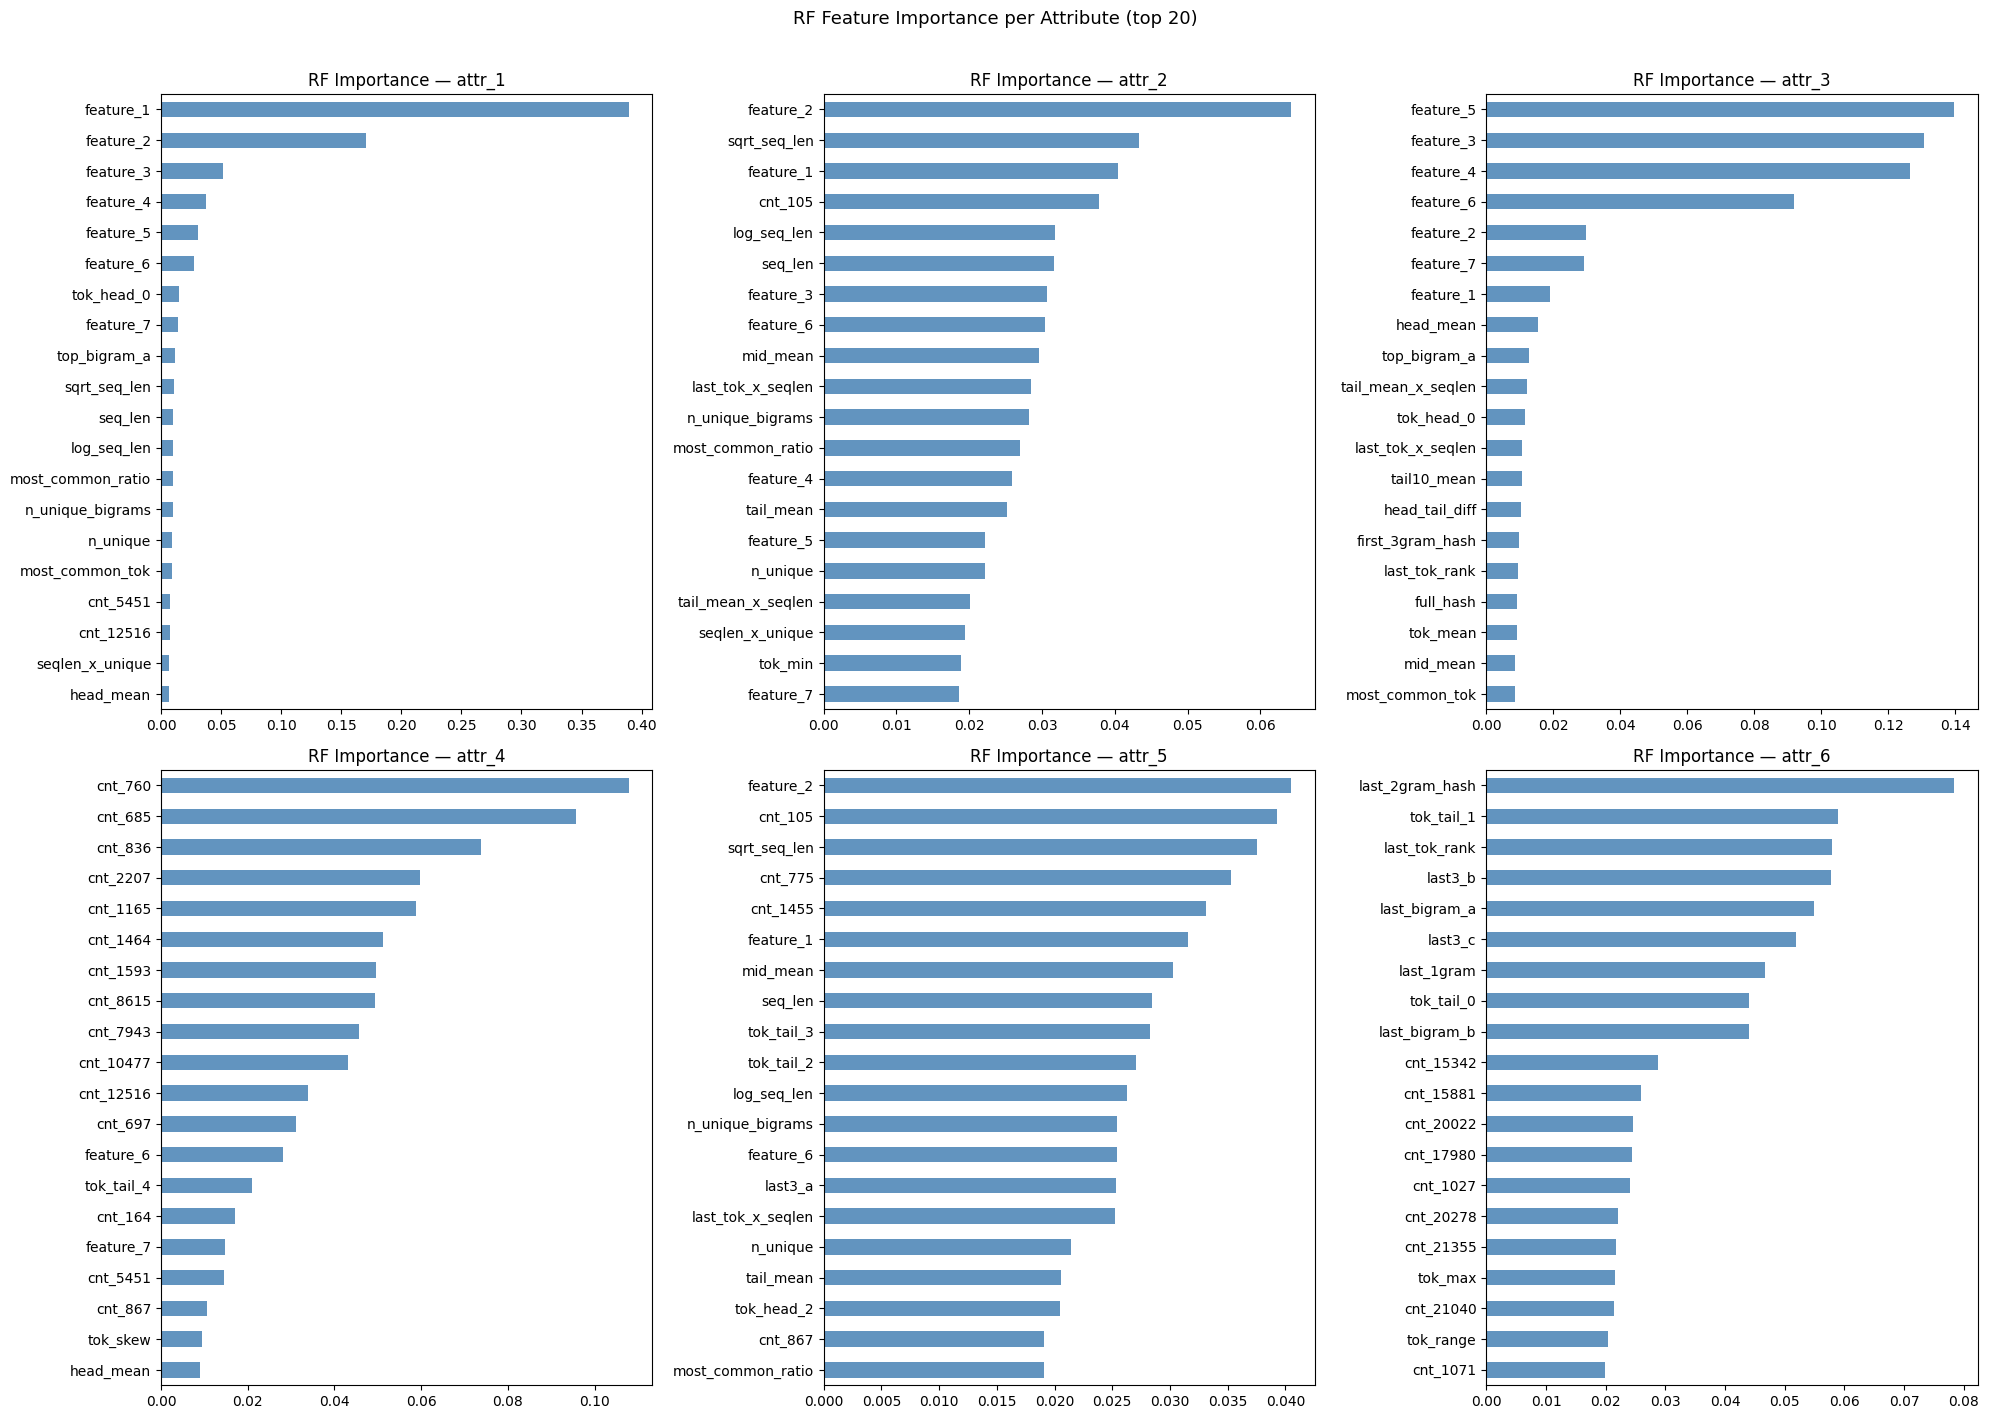


🏆 Global Top-20 (sum across all attrs):
feature_1            0.482831
feature_2            0.308351
feature_3            0.228115
feature_5            0.217173
feature_4            0.209592
feature_6            0.203761
cnt_760              0.110984
sqrt_seq_len         0.103783
cnt_685              0.097139
feature_7            0.092384
last_2gram_hash      0.088191
seq_len              0.081638
cnt_105              0.081121
mid_mean             0.080308
log_seq_len          0.080091
last3_b              0.077631
cnt_836              0.075813
n_unique_bigrams     0.075103
last_tok_rank        0.074447
last_tok_x_seqlen    0.073036


In [ ]:
print('Running RF importance (200 trees, max_depth=8)… ~2 min')
rf_imp_all = pd.Series(0.0, index=train_feats.columns)
fig, axes  = plt.subplots(2, 3, figsize=(20, 14))

for i, col in enumerate(TARGET_COLS):
    ax = axes[i//3][i%3]
    rf = RandomForestClassifier(n_estimators=200, max_depth=8, n_jobs=-1, random_state=42)
    rf.fit(train_feats, Y_train_enc[col])
    imp = pd.Series(rf.feature_importances_, index=train_feats.columns)
    rf_imp_all += imp
    imp.nlargest(20).plot(kind='barh', ax=ax, color='steelblue', alpha=.85)
    ax.set_title(f'RF Importance — {col}')
    ax.invert_yaxis()

plt.suptitle('RF Feature Importance per Attribute (top 20)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print('\n🏆 Global Top-20 (sum across all attrs):')
print(rf_imp_all.nlargest(20).to_string())

## 5. Feature Coverage Check — phân bố nhóm features quan trọng

Top-20 global features → Group phân loại:
  feature_1                           → G8 Meta
  feature_2                           → G8 Meta
  feature_3                           → G8 Meta
  feature_5                           → G8 Meta
  feature_4                           → G8 Meta
  feature_6                           → G8 Meta
  cnt_760                             → G6 BOW
  sqrt_seq_len                        → G1 Seq Stats
  cnt_685                             → G6 BOW
  feature_7                           → G8 Meta
  last_2gram_hash                     → G3 Chains
  seq_len                             → G1 Seq Stats
  cnt_105                             → G6 BOW
  mid_mean                            → G4 Statistical
  log_seq_len                         → G1 Seq Stats
  last3_b                             → G3 Chains
  cnt_836                             → G6 BOW
  n_unique_bigrams                    → G1 Seq Stats
  last_tok_rank                       → G5 Repetition
  last_tok_x_

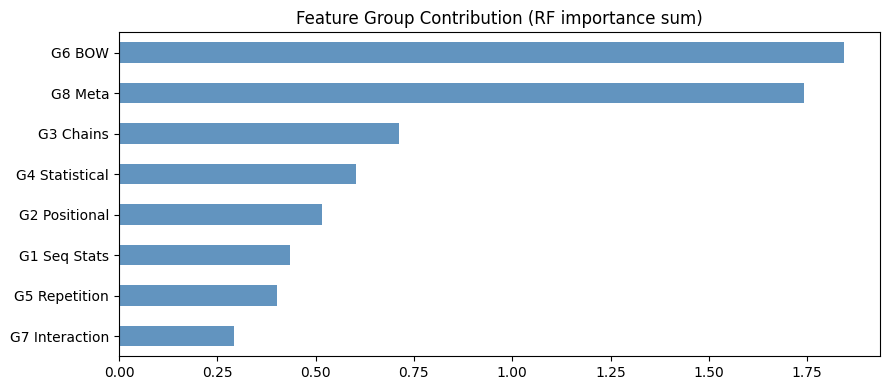

In [ ]:
# Xem top-20 global features thuộc nhóm nào
top20 = rf_imp_all.nlargest(20).index.tolist()
print('Top-20 global features → Group phân loại:')
for feat in top20:
    grp = 'Unknown'
    for g, cols in groups.items():
        if feat in cols:
            grp = g; break
    print(f'  {feat:35s} → {grp}')

# Tỷ lệ contribution từng group
contrib = {}
for g, cols in groups.items():
    valid = [c for c in cols if c in rf_imp_all.index]
    contrib[g] = rf_imp_all[valid].sum() if valid else 0

fig, ax = plt.subplots(figsize=(9, 4))
pd.Series(contrib).sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue', alpha=.85)
ax.set_title('Feature Group Contribution (RF importance sum)')
plt.tight_layout(); plt.show()

## 6. Save Features → NB-03

In [ ]:
train_feats.to_csv('/content/drive/MyDrive/sailormoon/data/pipeline/train_feats.csv')
val_feats.to_csv('/content/drive/MyDrive/sailormoon/data/pipeline/val_feats.csv')
test_feats.to_csv('/content/drive/MyDrive/sailormoon/data/pipeline/test_feats.csv')

feat_meta = {
    'all_cols'      : list(train_feats.columns),
    'groups'        : {g: cols for g, cols in groups.items()},
    'top_tokens'    : top_tokens,
    'rf_importance' : rf_imp_all.to_dict(),
    'top20_global'  : rf_imp_all.nlargest(20).index.tolist(),
    'n_features'    : train_feats.shape[1],
}
with open('/content/drive/MyDrive/sailormoon/data/pipeline/feat_meta.pkl', 'wb') as f:
    pickle.dump(feat_meta, f)

print('✅ Saved:')
print('   /content/drive/MyDrive/sailormoon/data/pipeline/train_feats.csv')
print('   /content/drive/MyDrive/sailormoon/data/pipeline/val_feats.csv')
print('   /content/drive/MyDrive/sailormoon/data/pipeline/test_feats.csv')
print('   /content/drive/MyDrive/sailormoon/data/pipeline/feat_meta.pkl')
print(f'\nTotal features: {train_feats.shape[1]}')



✅ Saved:
   /content/drive/MyDrive/sailormoon/data/pipeline/train_feats.csv
   /content/drive/MyDrive/sailormoon/data/pipeline/val_feats.csv
   /content/drive/MyDrive/sailormoon/data/pipeline/test_feats.csv
   /content/drive/MyDrive/sailormoon/data/pipeline/feat_meta.pkl

Total features: 121

➡️  Next: NB-03_lgbm_model.ipynb
